<br/>

<div align="center">
<span style="font-size: 2.5em;">SBI Inference Comparison</span>
<br/>
<span style="font-size: 1.2em; color: gray;">WimPy vs S1S2 signal-only vs S1S2 signal+background</span>
</div>

## Overview

This notebook compares inference results across three settings:
- **WimPy** (energy-space spectra)
- **S1S2 signal-only**
- **S1S2 signal+background**

**Workflow:**

1. **Setup**: Load models and data
2. **Posterior Comparison**: Plot posteriors in a 1x3 layout
3. **Exclusion Comparison**: Compare upper limits with background bands

**Note:** This notebook focuses on visualization; model training happens in the training scripts.

---

## 1. Setup and Configuration

Import required libraries and load the models/datasets for the three cases.

In [ ]:
import os
import numpy as np
import torch

desired_root_name = "xenon-sbi"
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

from configs.config import load_model, load_model_s1s2
from utils.posteriors import (
    plot_inference_comparison_1x3,
    plot_hpd_and_marginalized_comparison,
    generate_null_spectrum_s1s2,
)
from utils.processing import clean_nan_events, preprocess_features, SignalPlusBackgroundDataset

### Model and Data Configuration

Set the model names, data regimes, and paths used in this comparison.

In [ ]:
# WimPy settings
wimpy_modelname = "ntothighest"
wimpy_halo = "shm"
wimpy_datatag = "low"
wimpy_n_train = 300_000
wimpy_top_k = 10

# S1S2 settings
s1s2_modelname_only = "S1S2_signal"
s1s2_modelname_bg = "S1S2_signal_bg"
s1s2_halo = "shm"
s1s2_datatag = "low"
s1s2_n_train = 300_000
s1s2_bins = 10
mu_bg = 150

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load Trained Models

Load the pretrained WimPy and S1S2 models from their checkpoints.
Note: We need two separate S1S2 models (signal-only and signal+background).

In [ ]:
# WimPy model
wimpy_datapath = f"data/datasets/wimpy/{wimpy_halo}/wimpy_n{wimpy_n_train}_{wimpy_datatag}_{wimpy_halo}.pt"
wimpy_modelpath = f"models/wimpy/{wimpy_halo}/{wimpy_modelname}_n{wimpy_n_train}_{wimpy_datatag}_{wimpy_halo}.pt"
print(f"Loading WimPy model from:\n{wimpy_modelpath}\n")
model_wimpy, _ = load_model(wimpy_modelpath, wimpy_modelname, print_arch=False)

# S1S2 signal-only model
signal_type_only = "signal_only"
s1s2_modelpath_only = f"models/xenon/online/{signal_type_only}/{s1s2_halo}/{s1s2_modelname_only}_bins{s1s2_bins}_n{s1s2_n_train}_{s1s2_halo}.pt"
print(f"Loading S1S2 signal-only model from:\n{s1s2_modelpath_only}\n")
model_s1s2_only, _ = load_model_s1s2(
    s1s2_modelpath_only,
    bins=s1s2_bins,
    modelname=s1s2_modelname_only,
    device=device,
    print_arch=False,
 )

# S1S2 signal+background model
signal_type_bg = f"signal_bg_mu{mu_bg:.0f}"
s1s2_modelpath_bg = f"models/xenon/online/{signal_type_bg}/{s1s2_halo}/{s1s2_modelname_bg}_bins{s1s2_bins}_n{s1s2_n_train}_{s1s2_halo}.pt"
print(f"Loading S1S2 signal+bg model from:\n{s1s2_modelpath_bg}\n")
model_s1s2_bg, _ = load_model_s1s2(
    s1s2_modelpath_bg,
    bins=s1s2_bins,
    modelname=s1s2_modelname_bg,
    device=device,
    print_arch=False,
 )

Loading WimPy model from:
models/wimpy/shm/ntothighest_n300000_low_shm.pt

Loading S1S2 signal-only model from:
models/xenon/online/signal_only/shm/S1S2_signal_bins10_n300000_shm.pt

Loading S1S2 signal+bkg model from:
models/xenon/online/signal_bkg_mu150/shm/S1S2_signal_bg_bins10_n300000_shm.pt



### Load Datasets

Load the WimPy and S1S2 datasets once. These are shared for all comparisons.

In [ ]:
# Load WimPy dataset
wimpy_data = torch.load(wimpy_datapath, weights_only=False)
wimpy_feature_tensor = wimpy_data["features"]
wimpy_feature_tensor = preprocess_features(model_wimpy, wimpy_feature_tensor, device)
wimpy_theta_tensor = wimpy_data["theta"]

# Load S1S2 dataset
signal_pt = f"data/datasets/xenon/s1s2/pt/s1s2_n{s1s2_n_train}_{s1s2_halo}.pt"
signal_data = torch.load(signal_pt, weights_only=False)
energies_list = signal_data["events"]
cs1cs2_list = signal_data["cs1cs2"]
theta_tensor = signal_data["theta"]

energies_list, cs1cs2_list = clean_nan_events(energies_list, cs1cs2_list)

# Background pool
bg_csv = "data/datasets/xenon/s1s2/ers/s1s2_ers.csv"
bg_events = np.loadtxt(bg_csv, delimiter=",", skiprows=1, usecols=(0, 1))

# Create signal-only dataset for indexing
signal_dataset = SignalPlusBackgroundDataset(
    signal_events=cs1cs2_list,
    theta=theta_tensor,
    background_events=bg_events,
    mu_bg=0,
    s1_bins=s1s2_bins,
    s2_bins=s1s2_bins,
    reproducible=True,
    rng_seed=42,
)

print(f"Loaded {len(wimpy_feature_tensor)} events")

Loaded 300000 events


---

## 2. Comparison Functions

### Posterior Comparison

`compare_posteriors_for_event()` — plots posteriors for a specific parameter point across all three configurations.

In [ ]:
def compare_posteriors_for_event(target_mchi, target_cp, random_bg=False, y_quantity="cp", plot_official_xenonnt=False, save_path=None):
    """Compare posteriors for a specific parameter point across all three models."""
    target_logm = np.log10(target_mchi)
    target_logcp = np.log10(target_cp)
    target_point = torch.tensor([target_logm, target_logcp], dtype=torch.float32)

    distances = torch.norm(theta_tensor - target_point, dim=1)
    event_idx = torch.argmin(distances).item()

    actual_logm, actual_logcp = theta_tensor[event_idx]
    actual_mchi = 10 ** actual_logm.item()
    actual_cp = 10 ** actual_logcp.item()

    wimpy_counts = wimpy_feature_tensor[event_idx]
    s1s2_signal_counts, _ = signal_dataset[event_idx]
    s1s2_signal_counts = s1s2_signal_counts.view(-1)

    plot_inference_comparison_1x3(
        wimpy_counts=wimpy_counts,
        s1s2_signal_counts=s1s2_signal_counts,
        background_events=bg_events,
        mu_bg=mu_bg,
        model_wimpy=model_wimpy,
        model_s1s2_only=model_s1s2_only,
        model_s1s2_bg=model_s1s2_bg,
        random_bg=random_bg,
        mchi_true=actual_mchi,
        cp_true=actual_cp,
        y_quantity=y_quantity,
        plot_official_xenonnt=plot_official_xenonnt,
        save_path=save_path
    )

### Null Spectra for Exclusion Comparison

Create null (background-free) spectra used for expected sensitivity comparisons.

In [ ]:
wimpy_null = torch.zeros_like(wimpy_feature_tensor[0])
s1s2_null = generate_null_spectrum_s1s2(
    background_events=bg_events,
    mu_bg=0,
    s1_bins=s1s2_bins,
    s2_bins=s1s2_bins,
    rng_seed=0,
)

---

## 3. Run Comparisons

Execute the comparison functions defined above.

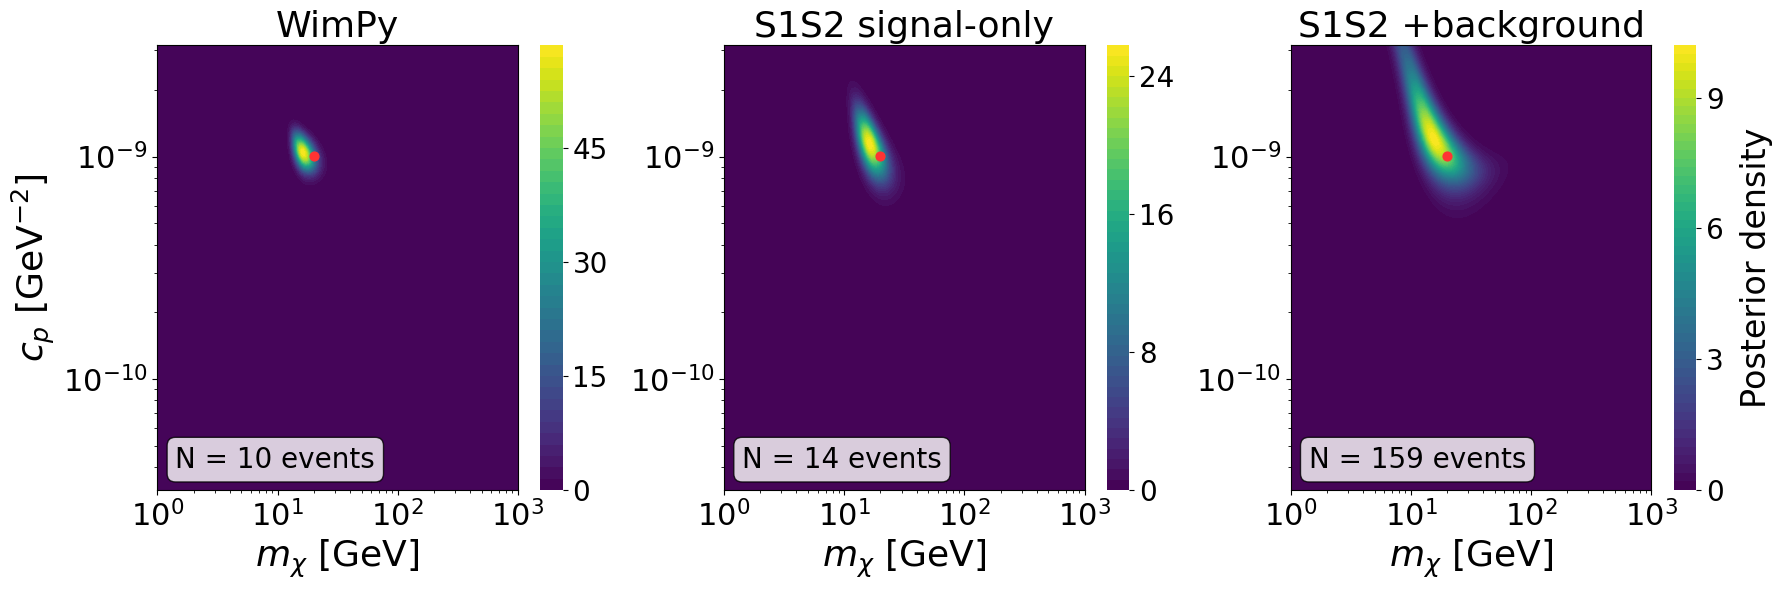

In [ ]:
compare_posteriors_for_event(
    target_mchi=20, 
    target_cp=10**(-9.0), 
    random_bg=True, 
    y_quantity="cp", 
    plot_official_xenonnt=False,
    #save_path=f"figures/chap7/posterior_comparison.pdf",
)

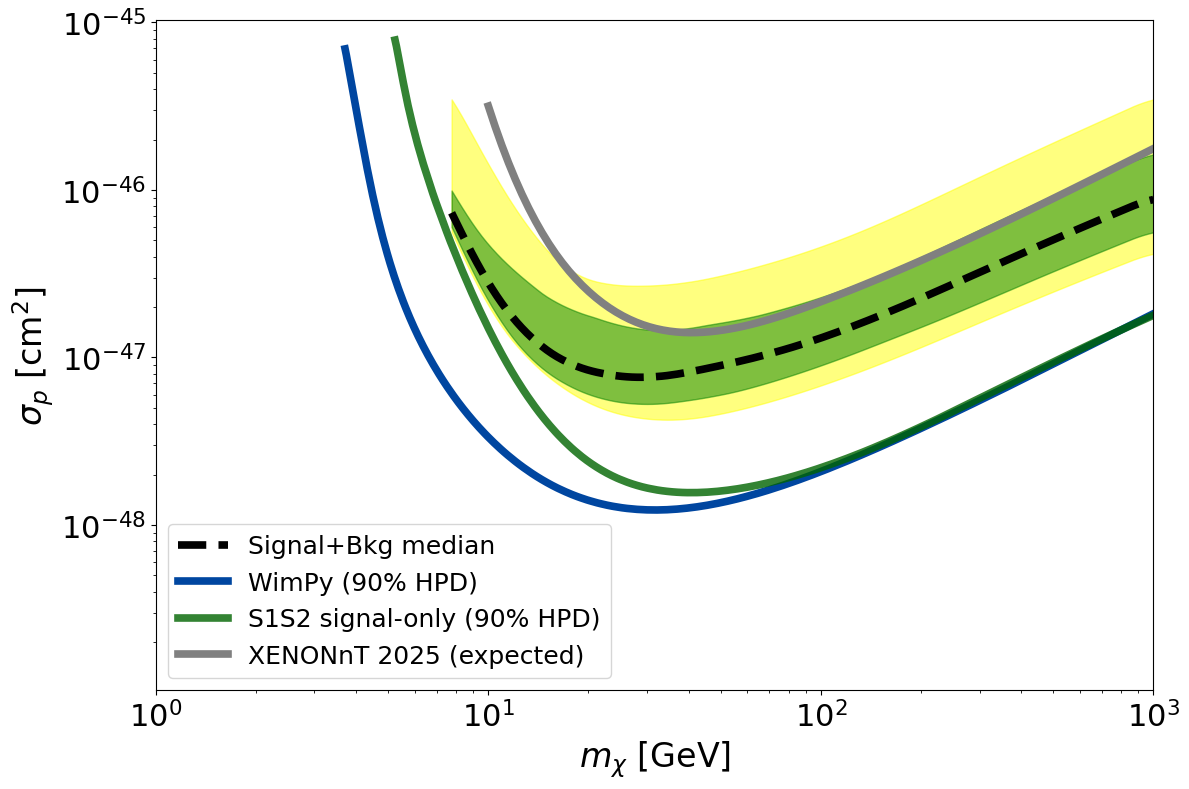

In [ ]:
plot_hpd_and_marginalized_comparison(
    wimpy_counts=wimpy_null,
    s1s2_signal_counts=s1s2_null,
    background_events=bg_events,
    mu_bg=mu_bg,
    model_wimpy=model_wimpy,
    model_s1s2_only=model_s1s2_only,
    model_s1s2_bg=model_s1s2_bg,
    n_realizations=50,
    y_quantity="sigma",
    plot_official_xenonnt=True,
    figsize=(12,8),
    axis_label_fontsize=24,
    tick_label_fontsize=22,
    title_fontsize=24,
    legend_fontsize=18,
    save_path="figures/chap7/sbi_comparison_hpd_marginalized.pdf"
)